<a href="https://colab.research.google.com/github/workshahnawaz643-tech/ShahFAML/blob/main/Journal1final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset Shape: (33, 11)
Expanded Dataset Shape: (2033, 8)

MODEL PERFORMANCE

Linear Regression
R2 Score: 0.7909074578670796
RMSE: 1.933312624576831
---------------------
Random Forest
R2 Score: 0.9922107406944153
RMSE: 0.3912395656876602
---------------------
Support Vector Machine
R2 Score: 0.8183719737891555
RMSE: 1.9051419649444732
---------------------
Gaussian Process
R2 Score: 0.9916292712207516
RMSE: 0.40995313671869554
---------------------
Gradient Boosting
R2 Score: 0.9899639059140894
RMSE: 0.37292894972796714
---------------------
Neural Network
R2 Score: 0.9971984760914613
RMSE: 0.22812455382337452
---------------------

BEST MODEL: Neural Network
BEST R2 SCORE: 0.9971984760914613


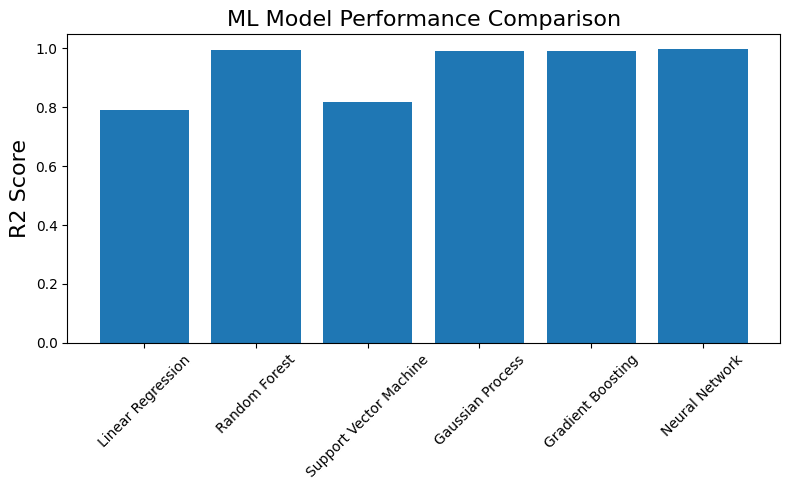

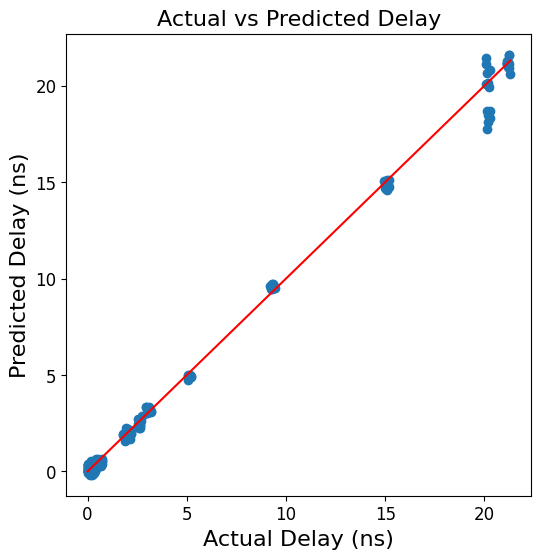

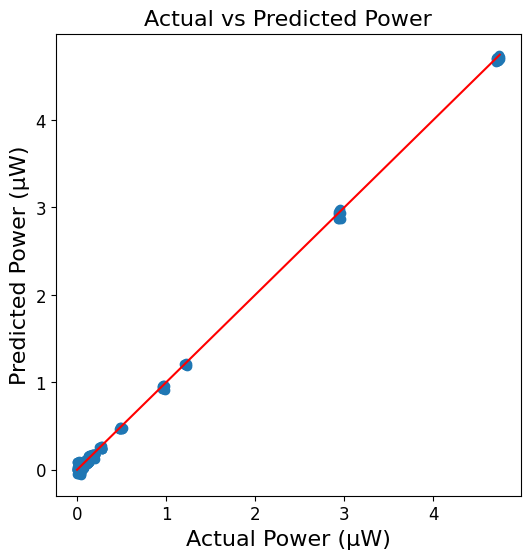

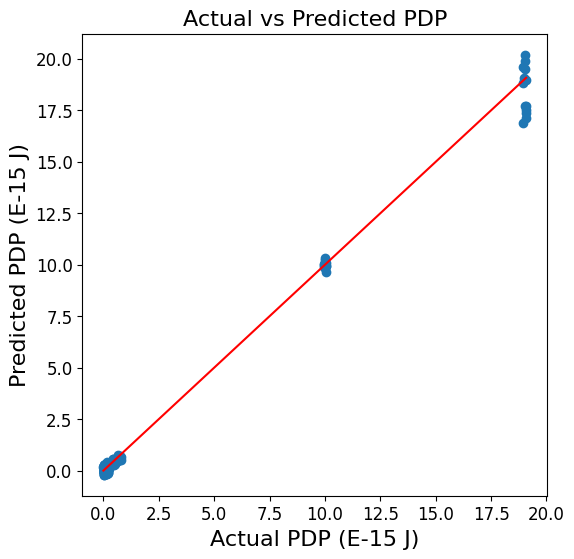

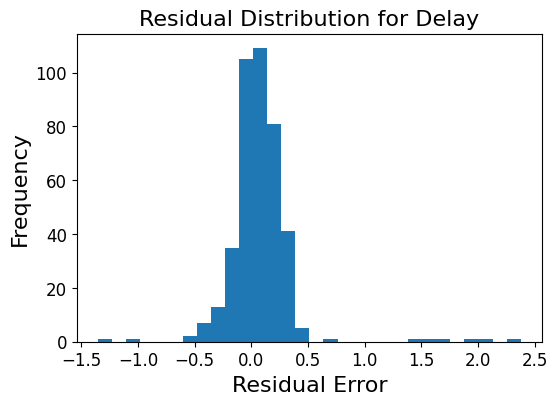

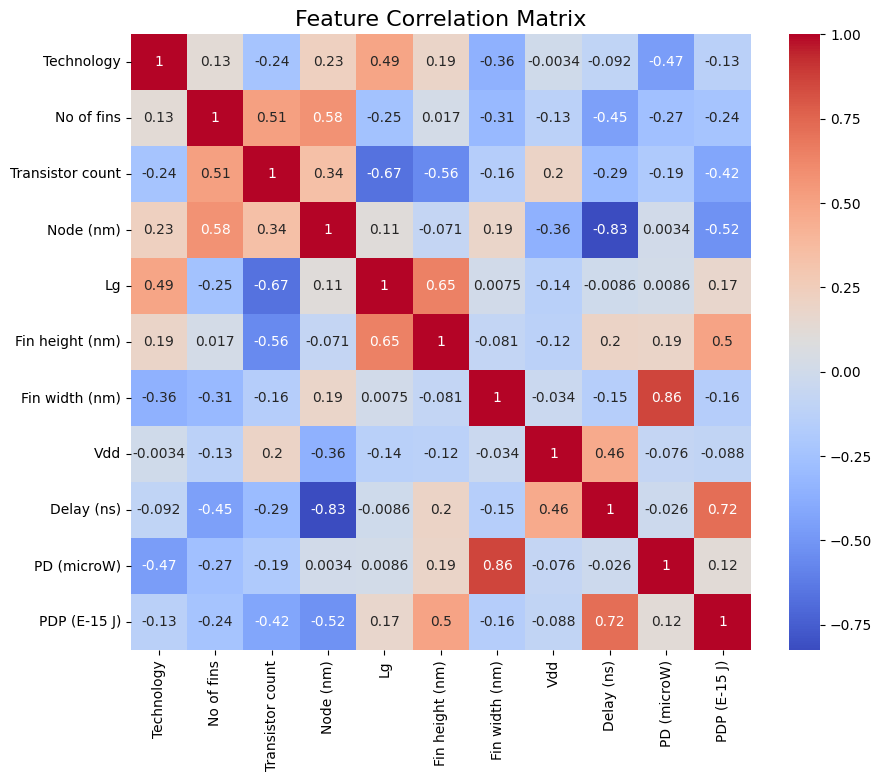

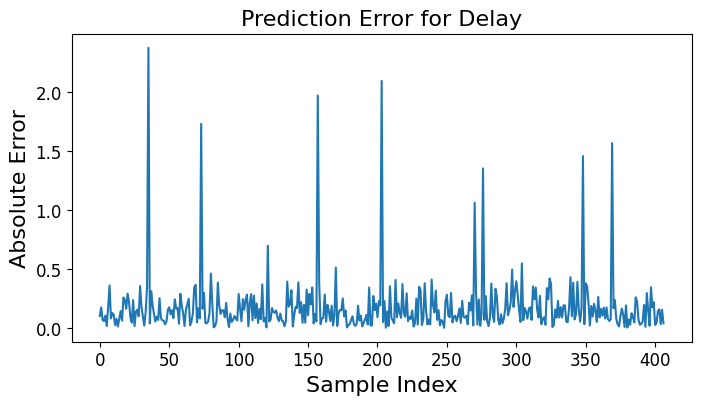

In [4]:
# ============================================
# FINFET FULL ADDER ML MODEL + MONTE CARLO DATA EXPANSION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ML MODELS
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor

# ============================================
# STEP 1 : LOAD DATASET
# ============================================

data = pd.read_csv("https://raw.githubusercontent.com/workshahnawaz643-tech/ShahFAML/refs/heads/main/Dataset1-3.csv")

print("Original Dataset Shape:", data.shape)

# ============================================
# STEP 2 : CLEAN DATA
# ============================================

data = data.dropna()

# Convert categorical technology to numbers
data['Technology'] = data['Technology'].astype('category').cat.codes

# ============================================
# STEP 3 : DEFINE INPUTS AND TARGETS
# ============================================

X = data.drop(columns=['Delay (ns)','PD (microW)','PDP (E-15 J)'])

y = data[['Delay (ns)','PD (microW)','PDP (E-15 J)']]

# ============================================
# STEP 4 : MONTE CARLO DATASET EXPANSION
# ============================================

def monte_carlo_expand(X, y, n_samples=1000, noise=0.05):

    X_new = []
    y_new = []

    for i in range(n_samples):

        idx = np.random.randint(0,len(X))

        x = X.iloc[idx].values
        target = y.iloc[idx].values

        # Add Gaussian noise
        x_new = x + np.random.uniform(0, noise*np.std(X.values,axis=0))
        y_new_val = target + np.random.uniform(0, noise*np.std(y.values,axis=0))

        X_new.append(x_new)
        y_new.append(y_new_val)

    X_new = np.array(X_new)
    y_new = np.array(y_new)

    X_expanded = np.vstack([X.values, X_new])
    y_expanded = np.vstack([y.values, y_new])

    return X_expanded, y_expanded


X_expanded, y_expanded = monte_carlo_expand(X,y,2000)

print("Expanded Dataset Shape:",X_expanded.shape)

# ============================================
# STEP 5 : TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42
)

# ============================================
# STEP 6 : NORMALIZATION
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# STEP 7 : DEFINE ML MODELS
# ============================================

models = {

"Linear Regression":
MultiOutputRegressor(LinearRegression()),

"Random Forest":
RandomForestRegressor(
n_estimators=300,
max_depth=12,
random_state=42
),

"Support Vector Machine":
MultiOutputRegressor(
SVR(kernel='rbf',C=10)
),

"Gaussian Process":
MultiOutputRegressor(
GaussianProcessRegressor()
),

"Gradient Boosting":
MultiOutputRegressor(
GradientBoostingRegressor()
),

"Neural Network":
MLPRegressor(
hidden_layer_sizes=(100,100),
max_iter=2000
)

}

# ============================================
# STEP 8 : TRAIN AND COMPARE MODELS
# ============================================

results = {}

print("\nMODEL PERFORMANCE\n")

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test,pred)

    rmse = np.sqrt(mean_squared_error(y_test,pred))

    results[name] = r2

    print(name)
    print("R2 Score:",r2)
    print("RMSE:",rmse)
    print("---------------------")

# ============================================
# STEP 9 : BEST MODEL
# ============================================

best_model = max(results,key=results.get)

print("\nBEST MODEL:",best_model)
print("BEST R2 SCORE:",results[best_model])

# ============================================
# STEP 10 : FEATURE IMPORTANCE (if RF)
# ============================================

if best_model == "Random Forest":

    rf = models["Random Forest"]

    importance = rf.feature_importances_

    feature_names = X.columns

    print("\nFeature Importance:\n")

    for f,i in zip(feature_names,importance):

        print(f,":",round(i,3))


        import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

names = list(results.keys())
scores = list(results.values())

plt.bar(names, scores)

plt.ylabel("R2 Score",fontsize=16)
plt.title("ML Model Performance Comparison",fontsize=16)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

pred_best = models[best_model].predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test[:,0], pred_best[:,0])

plt.xlabel("Actual Delay (ns)",fontsize=16)
plt.ylabel("Predicted Delay (ns)",fontsize=16)
plt.title("Actual vs Predicted Delay",fontsize=16)
plt.xticks(fontsize=12)  # Set x-tick font size
plt.yticks(fontsize=12)  # Set y-tick font size

plt.plot([y_test[:,0].min(), y_test[:,0].max()],
         [y_test[:,0].min(), y_test[:,0].max()],
         'r')

plt.show()



plt.figure(figsize=(6,6))

plt.scatter(y_test[:,1], pred_best[:,1])

plt.xlabel("Actual Power (µW)",fontsize=16)
plt.ylabel("Predicted Power (µW)",fontsize=16)
plt.title("Actual vs Predicted Power",fontsize=16)
plt.xticks(fontsize=12)  # Set x-tick font size
plt.yticks(fontsize=12)  # Set y-tick font size

plt.plot([y_test[:,1].min(), y_test[:,1].max()],
         [y_test[:,1].min(), y_test[:,1].max()],
         'r')

plt.show()



plt.figure(figsize=(6,6))

plt.scatter(y_test[:,2], pred_best[:,2])

plt.xlabel("Actual PDP (E-15 J)",fontsize=16)
plt.ylabel("Predicted PDP (E-15 J)",fontsize=16)
plt.title("Actual vs Predicted PDP",fontsize=16)
plt.xticks(fontsize=12)  # Set x-tick font size
plt.yticks(fontsize=12)  # Set y-tick font size

plt.plot([y_test[:,2].min(), y_test[:,2].max()],
         [y_test[:,2].min(), y_test[:,2].max()],
         'r')

plt.show()



residuals = y_test - pred_best

plt.figure(figsize=(6,4))

plt.hist(residuals[:,0], bins=30)

plt.xlabel("Residual Error",fontsize=16)
plt.ylabel("Frequency",fontsize=16)
plt.title("Residual Distribution for Delay",fontsize=16)
plt.xticks(fontsize=12)  # Set x-tick font size
plt.yticks(fontsize=12)  # Set y-tick font size

plt.show()



import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix",fontsize=16)

plt.show()


error = abs(y_test[:,0] - pred_best[:,0])

plt.figure(figsize=(8,4))

plt.plot(error)

plt.xlabel("Sample Index",fontsize=16)
plt.ylabel("Absolute Error",fontsize=16)
plt.xticks(fontsize=12)  # Set x-tick font size
plt.yticks(fontsize=12)  # Set y-tick font size
plt.title("Prediction Error for Delay",fontsize=16)

plt.show()



